In [ ]:
import pandas as pd

# Load raw data once
df = pd.read_csv("../../data/raw/hotels.csv", encoding="latin-1")
df.columns = df.columns.str.strip()

rating_map = {
    "OneStar": 1,
    "TwoStar": 2,
    "ThreeStar": 3,
    "FourStar": 4,
    "FiveStar": 5,
}

df["hotel_star_rating"] = df["HotelRating"].map(rating_map)

df["facility_count"] = df["HotelFacilities"].fillna("").apply(lambda x: len(str(x).split()))
df["description_length"] = df["Description"].fillna("").apply(len)
df["has_attractions"] = df["Attractions"].notna().astype(int)

coords = df["Map"].str.split("|", expand=True)
df["latitude"] = pd.to_numeric(coords[0], errors="coerce")
df["longitude"] = pd.to_numeric(coords[1], errors="coerce")

# Save processed data as parquet
df.to_parquet("../../data/processed/hotels_clean_expanded.parquet", index=False)

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import mannwhitneyu
import statsmodels.api as sm

"""
These analyses expand upon our EDA by adding derived features,
effect sizes, non-parametric tests, regression checks, diagnostics,
and interpretation fields.
"""

# Load cleaned data
df = pd.read_parquet("../data/processed/hotels_clean_expanded.parquet")

# Convert hotel rating to numeric
rating_map = {
    "OneStar": 1,
    "TwoStar": 2,
    "ThreeStar": 3,
    "FourStar": 4,
    "FiveStar": 5,
}

df["hotel_star_rating"] = df["HotelRating"].map(rating_map)

# Create expanded EDA features
df["facility_count"] = df["HotelFacilities"].fillna("").apply(lambda x: len(str(x).split()))
df["description_length"] = df["Description"].fillna("").apply(len)
df["has_attractions"] = df["Attractions"].notna().astype(int)

# Optional: split map into latitude/longitude safely
coords = df["Map"].str.split("|", expand=True)

df["latitude"] = pd.to_numeric(coords[0], errors="coerce")
df["longitude"] = pd.to_numeric(coords[1], errors="coerce")


# Effect size analysis
def _effect_size_analysis(high_group, low_group) -> dict[str, float]:
    n1, n2 = len(high_group), len(low_group)
    var1, var2 = high_group.var(ddof=1), low_group.var(ddof=1)

    pooled_sd = np.sqrt(
        ((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)
    )

    cohens_d = (high_group.mean() - low_group.mean()) / pooled_sd

    return {
        "cohens_d": float(cohens_d),
    }


# Non-parametric test alongside the t-test
def _nonparametric_test(high_group, low_group) -> dict[str, float | str]:
    u_stat, p_value = mannwhitneyu(
        high_group,
        low_group,
        alternative="two-sided"
    )

    return {
        "test": "Mann–Whitney U",
        "u_statistic": float(u_stat),
        "p_value": float(p_value),
    }


# Lightweight regression block
def _regression_test(df, feature, target) -> dict[str, float | str | int]:
    test_df = df.dropna(subset=[feature, target])

    X = sm.add_constant(test_df[feature])
    y = test_df[target]

    model = sm.OLS(y, X).fit()

    return {
        "test": "OLS regression",
        "n": int(len(test_df)),
        "coefficient": float(model.params[feature]),
        "p_value": float(model.pvalues[feature]),
        "r_squared": float(model.rsquared),
    }


# Interpretation fields
def _interpret_p(p: float) -> str:
    if p < 0.01:
        return "strong evidence against null"
    elif p < 0.05:
        return "moderate evidence against null"
    else:
        return "no significant evidence"


def _interpret_effect_size(d: float) -> str:
    d = abs(d)

    if d < 0.2:
        return "negligible"
    elif d < 0.5:
        return "small"
    elif d < 0.8:
        return "medium"
    else:
        return "large"


# Feature diagnostics
def _feature_diagnostics(df, feature) -> dict[str, float | int]:
    return {
        "skewness": float(df[feature].skew()),
        "unique_values": int(df[feature].nunique()),
        "missing_values": int(df[feature].isna().sum()),
    }

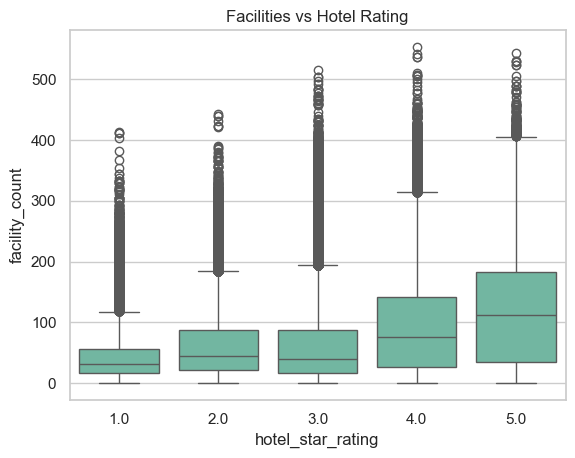

/var/folders/m8/fn54_3_91sv4p_6pnwl6zyhr0000gn/T/ipykernel_86502/3140426946.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


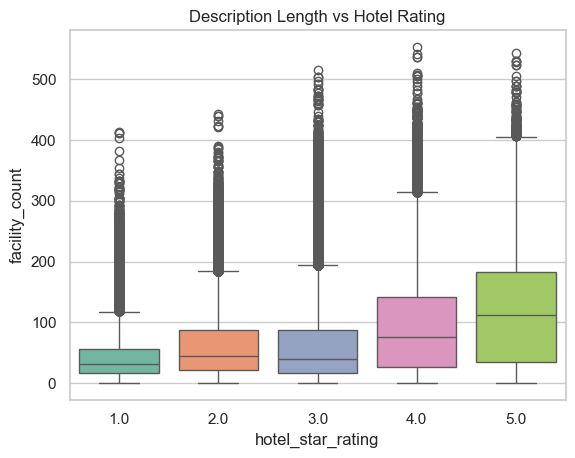

/var/folders/m8/fn54_3_91sv4p_6pnwl6zyhr0000gn/T/ipykernel_86502/3140426946.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


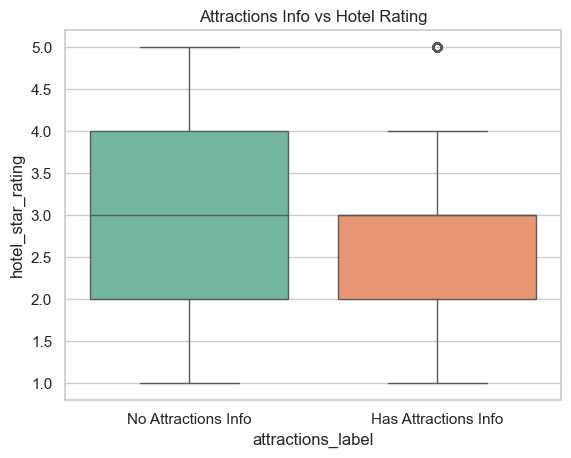

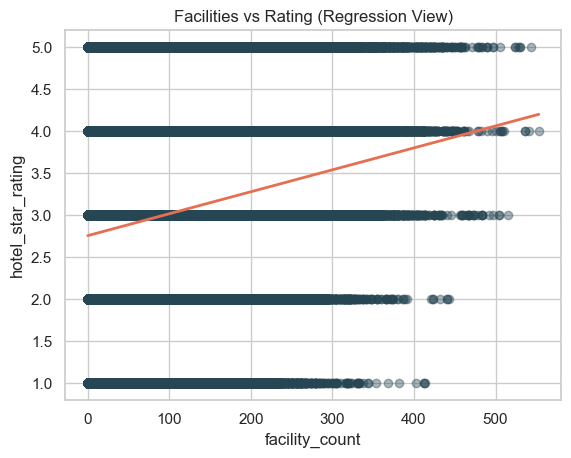

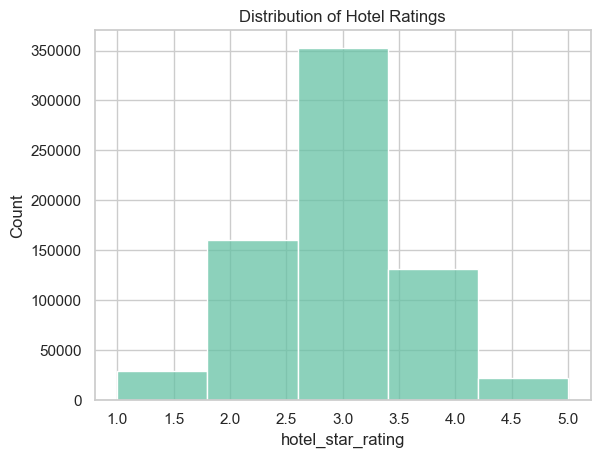

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="Set2")
df["attractions_label"] = df["has_attractions"].map({
    0: "No Attractions Info",
    1: "Has Attractions Info"
})

sns.boxplot(x="hotel_star_rating", y="facility_count", data=df)
plt.title("Facilities vs Hotel Rating")
plt.show()

sns.boxplot(
    x="hotel_star_rating",
    y="facility_count",
    data=df,
    palette="Set2"
)
plt.title("Description Length vs Hotel Rating")
plt.show()


sns.boxplot(
    x="attractions_label",
    y="hotel_star_rating",
    data=df,
    palette="Set2"
)
plt.title("Attractions Info vs Hotel Rating")
plt.show()

sns.regplot(
    x="facility_count",
    y="hotel_star_rating",
    data=df,
    scatter_kws={
        "alpha": 0.4,
        "color": "#264653"   # dark blue/teal
    },
    line_kws={
        "color": "#e76f51",  # strong contrast (reddish)
        "linewidth": 2
    }
)
plt.title("Facilities vs Rating (Regression View)")
plt.show()

sns.histplot(df["hotel_star_rating"], bins=5)
plt.title("Distribution of Hotel Ratings")
plt.show()
